## installing the dataset

In [3]:
#from milliontrees.common.data_loaders import get_train_loader
#from milliontrees.datasets.TreeBoxes import TreeBoxesDataset
#from milliontrees.datasets.TreePoints import TreePointsDataset
#from milliontrees.datasets.TreePolygons import TreePolygonsDataset

## boxes

#dataBoxes = TreeBoxesDataset(download=True,mini=True)
#trainBoxes = dataBoxes.get_subset("train")
#train_loaderBoxes = get_train_loader("standard", trainBoxes, batch_size=2)

#splitBoxes = pd.read_csv("data/TreeBoxes_v0.11/random.csv") 


## points

#dataPoints = TreePointsDataset(download=True,mini=True)
#trainPoints = dataPoints.get_subset("train")
#train_loaderPoints = get_train_loader("standard", trainPoints, batch_size=2)

## polygons

#dataPolygons = TreePolygonsDataset(download=True,mini=True)
#trainPolygons = dataPolygons.get_subset("train")
#train_loaderPolygons = get_train_loader("standard", trainPolygons, batch_size=2)



In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from milliontrees.datasets.TreeBoxes import TreeBoxesDataset


In [5]:
#dataBoxes = TreeBoxesDataset(download=True, mini=True)
#trainBoxes = dataBoxes.get_subset("train")

split_path = "data/TreeBoxes_v0.11/random.csv"
split_df = pd.read_csv(split_path)
    
print("Number of rows in split:", len(split_df))


Number of rows in split: 15246


## EDA

In [6]:
split_df.head()

,filename,xmin,ymin,xmax,ymax,geometry,label,source,Unnamed: 0,existing_split,...,tile_name,metadata,treeID,Z,complete,basename,remove,image_path,annotator,split
0,5030-10-4.png,0.0,354.0,21.0,400.0,"POLYGON ((21 354, 21 400, 0 400, 0 354, 21 354))",Tree,Sun et al. 2022,NaN,NaN,...,NaN,NaN,NaN,NaN,True,5030-10-4.png,NaN,NaN,NaN,train
1,5030-10-4.png,0.0,401.0,50.0,444.0,"POLYGON ((50 401, 50 444, 0 444, 0 401, 50 401))",Tree,Sun et al. 2022,NaN,NaN,...,NaN,NaN,NaN,NaN,True,5030-10-4.png,NaN,NaN,NaN,train
2,5030-10-4.png,16.0,492.0,59.0,536.0,"POLYGON ((59 492, 59 536, 16 536, 16 492, 59 4...",Tree,Sun et al. 2022,NaN,NaN,...,NaN,NaN,NaN,NaN,True,5030-10-4.png,NaN,NaN,NaN,train
3,5030-10-4.png,167.0,657.0,194.0,684.0,"POLYGON ((194 657, 194 684, 167 684, 167 657, ...",Tree,Sun et al. 2022,NaN,NaN,...,NaN,NaN,NaN,NaN,True,5030-10-4.png,NaN,NaN,NaN,train
4,5030-10-4.png,200.0,662.0,242.0,705.0,"POLYGON ((242 662, 242 705, 200 705, 200 662, ...",Tree,Sun et al. 2022,NaN,NaN,...,NaN,NaN,NaN,NaN,True,5030-10-4.png,NaN,NaN,NaN,train


In [7]:
row = split_df.iloc[1000] 
print("Selected row:")
print(row)

image_filename = row["filename"]
xmin = float(row["xmin"])
ymin = float(row["ymin"])
xmax = float(row["xmax"])
ymax = float(row["ymax"])

images_dir = os.path.join("data", "TreeBoxes_v0.11", "images")
image_path = os.path.join(images_dir, image_filename)

print("Image path:", image_path)
assert os.path.exists(image_path), f"Image not found: {image_path}"



Selected row:
filename                                                5032-6-6.png
xmin                                                           645.0
ymin                                                           853.0
xmax                                                           785.0
ymax                                                           968.0
geometry           POLYGON ((785 853, 785 968, 645 968, 645 853, ...
label                                                           Tree
source                                               Sun et al. 2022
Unnamed: 0                                                       NaN
existing_split                                                   NaN
individual                                                       NaN
classifica                                                       NaN
user_name                                                        NaN
created_at                                                       NaN
subject_id          

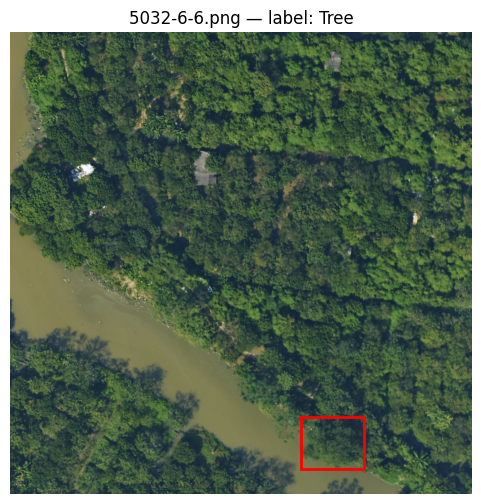

In [8]:
img = plt.imread(image_path)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img)
ax.set_title(f"{image_filename} — label: {row['label']}")


width = xmax - xmin
height = ymax - ymin

rect = patches.Rectangle(
    (xmin, ymin),
    width,
    height,
    linewidth=2,
    edgecolor="red",
    facecolor="none",
)
ax.add_patch(rect)

ax.axis("off")
plt.show()


In [9]:
from pathlib import Path
import shutil

# saving
folder = Path("eda_bbox")
if os.path.exists(folder):
    shutil.rmtree(folder)
os.makedirs(folder)


def plot_boxes(file_name,rows):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img)
    #ax.set_title(image_filename)
    ax.set_title(f"{image_filename} — {len(rows)} trees")

    for _, r in rows.iterrows():
        xmin, ymin, xmax, ymax = r[["xmin", "ymin", "xmax", "ymax"]].astype(float)
        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=1.5,
            edgecolor="red",
            facecolor="none",
        )
        ax.add_patch(rect)

    ax.axis("off")
    output = Path(f"eda_bbox/{file_name}")

    plt.savefig(output)
    plt.show

    return ax


## removing deleted files

In [ ]:
deleted_files_path = Path("data/trash/list.txt")
old_path = Path("data/TreeBoxes_v0.11/random_old.csv")
newdf_path = Path("data/TreeBoxes_v0.11/random.csv")   

df = pd.read_csv(old_path)

with open(deleted_files_path, "r", encoding="utf-8") as f:
    deleted_files = {line.strip() for line in f if line.strip()}

df = df[~df["filename"].astype(str).isin(deleted_files)]
df.to_csv(newdf_path,index=False)

print(f"Saved {len(df)} rows to {newdf_path}")


Saved 13577 rows to data/TreeBoxes_v0.11/random.csv


In [ ]:
split_path = "data/TreeBoxes_v0.11/random.csv"
split_df = pd.read_csv(split_path)
unique_filenames = split_df["filename"].unique()
images_dir = os.path.join("data", "TreeBoxes_v0.11", "images")
total = 0

# saving
folder = Path("eda_bbox")
if os.path.exists(folder):
    shutil.rmtree(folder)
os.makedirs(folder)


for image_filename in unique_filenames:    
    image_path = os.path.join(images_dir, image_filename)
    img = plt.imread(image_path)
    
    image_rows = split_df[split_df["filename"] == image_filename]
    
    total += len(image_rows)
    plot_boxes(image_filename,image_rows)

/tmp/ipykernel_341547/3698518669.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(6, 6))
